# Does Price Determine What Gets Read?
## Kindle Marketplace Discoverability Analysis

**Question:** Does pricing model — specifically Kindle Unlimited inclusion 
and price tier — structurally determine which books get discovered on Amazon?

**Dataset:** 133,102 Amazon Kindle book listings (2023)  
**Discoverability signals:** Bestseller rank, review count, Editors Pick, Goodreads Choice  
**Key variable:** Kindle Unlimited status (included in subscription vs paid separately)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All imports successful")

All imports successful


In [4]:
df = pd.read_csv('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/data/kindle_data-v2.csv')

print("Shape:", df.shape)
print("\nColumns:")
for col in df.columns:
    print(" -", col)
print("\nSample row:")
print(df.iloc[0])

Shape: (133102, 16)

Columns:
 - asin
 - title
 - author
 - soldBy
 - imgUrl
 - productURL
 - stars
 - reviews
 - price
 - isKindleUnlimited
 - category_id
 - isBestSeller
 - isEditorsPick
 - isGoodReadsChoice
 - publishedDate
 - category_name

Sample row:
asin                                                        B00TZE87S4
title                Adult Children of Emotionally Immature Parents...
author                                               Lindsay C. Gibson
soldBy                                         Amazon.com Services LLC
imgUrl               https://m.media-amazon.com/images/I/713KZTsaYp...
productURL                        https://www.amazon.com/dp/B00TZE87S4
stars                                                              4.8
reviews                                                              0
price                                                             9.99
isKindleUnlimited                                                False
category_id                      

In [5]:
# Basic overview of key columns
print("=== PRICE ===")
print(df['price'].describe())
print("\nZero price count:", (df['price'] == 0).sum())

print("\n=== STARS ===")
print(df['stars'].describe())
print("Zero stars (unrated):", (df['stars'] == 0).sum())

print("\n=== REVIEWS ===")
print(df['reviews'].describe())

print("\n=== BOOLEAN COLUMNS ===")
print("Kindle Unlimited:", df['isKindleUnlimited'].value_counts().to_dict())
print("Bestseller:", df['isBestSeller'].value_counts().to_dict())
print("Editors Pick:", df['isEditorsPick'].value_counts().to_dict())
print("Goodreads Choice:", df['isGoodReadsChoice'].value_counts().to_dict())

print("\n=== TOP 10 CATEGORIES ===")
print(df['category_name'].value_counts().head(10))

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== PRICE ===
count    133102.000000
mean         15.134127
std          22.254986
min           0.000000
25%           4.990000
50%           9.990000
75%          14.990000
max         682.000000
Name: price, dtype: float64

Zero price count: 4066

=== STARS ===
count    133102.000000
mean          4.404090
std           0.745646
min           0.000000
25%           4.400000
50%           4.500000
75%           4.700000
max           5.000000
Name: stars, dtype: float64
Zero stars (unrated): 3182

=== REVIEWS ===
count    133102.000000
mean        887.375779
std        5104.878777
min           0.000000
25%           0.000000
50%           4.000000
75%         365.000000
max      618227.000000
Name: reviews, dtype: float64

=== BOOLEAN COLUMNS ===
Kindle Unlimited: {False: 97287, True: 35815}
Bestseller: {False: 130866, True: 2236}
Editors Pick: {False: 127481, True: 5621}
Goodreads Choice: {False: 131700, True: 1402}

=== TOP 10 CATEGORIES ===
category_name
Mystery, Thriller & Suspe

In [6]:
# Create clean working copy
df_clean = df.copy()

# Drop columns we won't use
df_clean = df_clean.drop(columns=['asin', 'imgUrl', 'productURL', 
                                   'soldBy', 'category_id', 'publishedDate'])

# Remove unrated books (zero stars) — can't analyse discoverability 
# for books with no rating signal
df_clean = df_clean[df_clean['stars'] > 0]

# Create price tier column
df_clean['price_tier'] = pd.cut(
    df_clean['price'],
    bins=[-0.01, 0, 4.99, 9.99, 14.99, 999],
    labels=['Free', 'Under $5', '$5-$10', '$10-$15', 'Over $15']
)

# Create review tier for engagement analysis
df_clean['engagement'] = pd.cut(
    df_clean['reviews'],
    bins=[-1, 0, 10, 100, 1000, 999999],
    labels=['No Reviews', 'Low', 'Medium', 'High', 'Viral']
)

print("Clean dataset shape:", df_clean.shape)
print("\nPrice tier distribution:")
print(df_clean['price_tier'].value_counts().sort_index())
print("\nEngagement distribution:")
print(df_clean['engagement'].value_counts().sort_index())

Clean dataset shape: (129920, 12)

Price tier distribution:
price_tier
Free         3968
Under $5    29880
$5-$10      41786
$10-$15     26934
Over $15    27352
Name: count, dtype: int64

Engagement distribution:
engagement
No Reviews    61488
Low            4161
Medium        15120
High          29528
Viral         19623
Name: count, dtype: int64


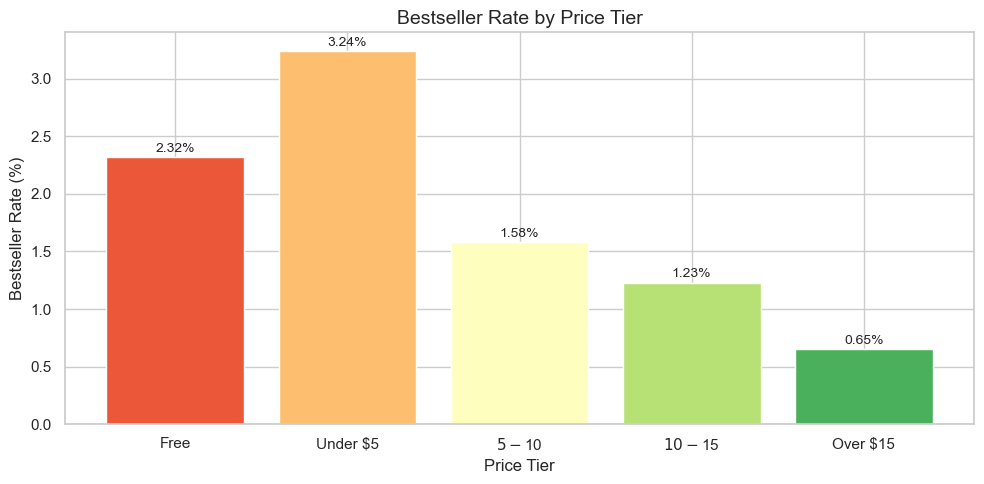

Saved to outputs/


In [8]:
# Chart 1 — Bestseller rate by price tier
bestseller_by_price = df_clean.groupby('price_tier', observed=True)['isBestSeller'].mean().reset_index()
bestseller_by_price['bestseller_pct'] = (bestseller_by_price['isBestSeller'] * 100).round(2)

fig, ax = plt.subplots()
colors = sns.color_palette('RdYlGn', len(bestseller_by_price))
bars = ax.bar(bestseller_by_price['price_tier'], bestseller_by_price['bestseller_pct'], color=colors)

for bar, val in zip(bars, bestseller_by_price['bestseller_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val}%', ha='center', va='bottom', fontsize=10)

ax.set_title('Bestseller Rate by Price Tier')
ax.set_xlabel('Price Tier')
ax.set_ylabel('Bestseller Rate (%)')
plt.tight_layout()
plt.savefig('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/outputs/bestseller_by_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

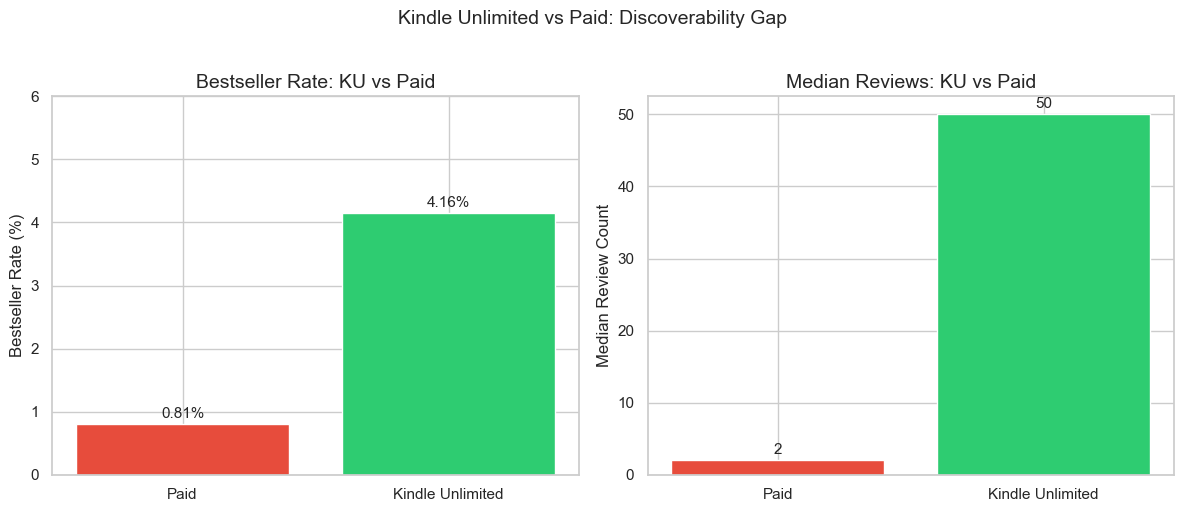

Saved to outputs/


In [10]:
# Chart 2 — Kindle Unlimited vs Paid: Bestseller rate and median reviews
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left chart — bestseller rate
ku_bestseller = df_clean.groupby('isKindleUnlimited')['isBestSeller'].mean() * 100
ku_labels = ['Paid', 'Kindle Unlimited']
colors = ['#e74c3c', '#2ecc71']

bars = axes[0].bar(ku_labels, ku_bestseller.values, color=colors)
for bar, val in zip(bars, ku_bestseller.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Bestseller Rate: KU vs Paid')
axes[0].set_ylabel('Bestseller Rate (%)')
axes[0].set_ylim(0, 6)

# Right chart — median reviews
ku_reviews = df_clean.groupby('isKindleUnlimited')['reviews'].median()
bars2 = axes[1].bar(ku_labels, ku_reviews.values, color=colors)
for bar, val in zip(bars2, ku_reviews.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Median Reviews: KU vs Paid')
axes[1].set_ylabel('Median Review Count')

plt.suptitle('Kindle Unlimited vs Paid: Discoverability Gap', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/outputs/ku_vs_paid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

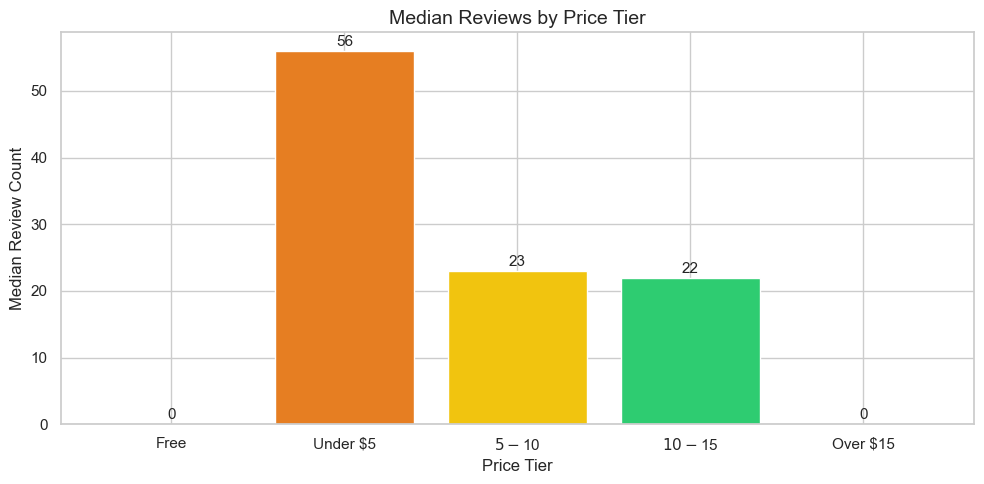

Saved to outputs/


In [12]:
# Chart 3 — Median reviews by price tier
reviews_by_price = df_clean.groupby('price_tier', observed=True)['reviews'].median().reset_index()

fig, ax = plt.subplots()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(reviews_by_price['price_tier'], reviews_by_price['reviews'], color=colors)

for bar, val in zip(bars, reviews_by_price['reviews']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=11)

ax.set_title('Median Reviews by Price Tier')
ax.set_xlabel('Price Tier')
ax.set_ylabel('Median Review Count')
plt.tight_layout()
plt.savefig('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/outputs/reviews_by_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

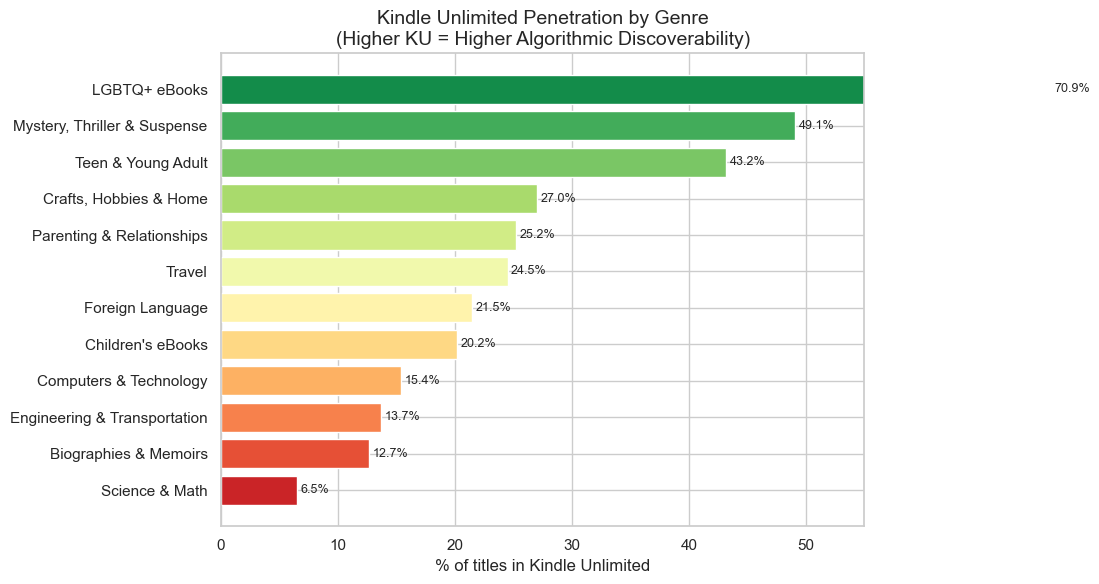

Saved to outputs/


In [14]:
# Chart 4 — KU penetration and bestseller rate by top genres
top_genres = df_clean['category_name'].value_counts().head(12).index
genre_df = df_clean[df_clean['category_name'].isin(top_genres)]

genre_stats = genre_df.groupby('category_name').agg(
    ku_rate=('isKindleUnlimited', 'mean'),
    bestseller_rate=('isBestSeller', 'mean'),
    median_reviews=('reviews', 'median')
).round(3).reset_index()

genre_stats = genre_stats.sort_values('ku_rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(genre_stats['category_name'], 
               genre_stats['ku_rate'] * 100,
               color=sns.color_palette('RdYlGn', len(genre_stats)))

for bar, val in zip(bars, genre_stats['ku_rate'] * 100):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_title('Kindle Unlimited Penetration by Genre\n(Higher KU = Higher Algorithmic Discoverability)')
ax.set_xlabel('% of titles in Kindle Unlimited')
ax.set_xlim(0, 55)
plt.tight_layout()
plt.savefig('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/outputs/ku_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

## Key Findings

| Finding | Data |
|---|---|
| KU bestseller rate vs Paid | 4.16% vs 0.81% — 5x higher |
| KU median reviews vs Paid | 50 vs 2 — 25x higher |
| Over $15 median reviews | 0 — effectively invisible |
| Under $5 sweet spot | 56 median reviews — highest engagement |
| LGBTQ+ eBooks KU penetration | 70.9% — most algorithmically advantaged genre |
| Science & Math KU penetration | 6.5% — most structurally disadvantaged |
| Books with zero reviews | 47% of entire catalogue |

**Core insight:** Kindle Unlimited creates a two-track discovery system. 
Genre fiction authors who enrol in KU get 5x the bestseller rate and 25x 
the reader engagement of paid titles. Non-fiction, academic, and technical 
authors are almost entirely outside this system and compete at a structural 
disadvantage regardless of quality or price.

**Strategic implication for independent authors:** Enrolling in KU is not 
just a pricing decision — it is a discoverability decision. For genre fiction, 
staying outside KU means accepting near-invisibility in algorithmic rankings.